# **CESM amip water tracer - temporal analysis**
Plots regarding variations in time 
Another notebook is also time-oriented but focus on the ENSO patterns

This notebook requires a prior storage of integrated water vapour (cell 22 of Sanity checks notebook)

## **Initial Set Up-related**

### Imports

In [1]:
%matplotlib inline
########## OS Interaction ##########
import os
import sys
import cftime

########## General ##########
import numpy as np
import netCDF4 as nc
import xarray as xr
import scipy as sp
import pandas as pd
import numpy as np
import numpy.ma as ma
import matplotlib.colors as colors 
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import ticker
from matplotlib import gridspec
import dask
import dask.bag as db
from dask.diagnostics import ProgressBar

########## Cartopy+ Shapely ##########
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing
from mpl_toolkits.axes_grid1 import make_axes_locatable


### Function Definitions

In [2]:
# Overall: unstacks time for an input data set
def unstack_time(ds_in):

    # Groups by year or months , calculates the mean, then takes/assigns the resulting values
    years = ds_in.groupby('time.year').mean('time').year
    months = ds_in.groupby('time.month').mean('time').month

    # Makes a pandas MultiIndex that is years x months
    midx = pd.MultiIndex.from_product([years.values,months.values], names=("year","month"))

    # Creates a temporary data set copy from ds_in, multiindex yxm and assign it 
    ds_temp = ds_in.copy()
    ds_temp = ds_temp.assign_coords({'time':midx})
    ds_out = ds_temp.unstack()
    return ds_out

##########

# Overall: creates a vertical integration function accounting for totpography and surface pressure
def vert_int_hybrid(ds, var, ds_hybrid):
    g    = 9.80665   # m/s²
    P0   = 100000.   # Pa  (standard reference pressure)

    q    = ds[var]
    PS   = ds_hybrid['PS']    # surface pressure  (Pa)
    hyai = ds_hybrid['hyai']  # interface A coefficients
    hybi = ds_hybrid['hybi']  # interface B coefficients

    # Interface pressures at every grid point & level interface
    P_i = hyai * P0 + hybi * PS          # shape: (time, ilev, lat, lon)

    # Pressure thickness of each model layer
    dp = P_i.diff(dim='ilev')            # shape: (time, ilev-1, lat, lon)
    dp = dp.transpose("time", "ilev", "lat", "lon")

    # Copy dp into a DataArray that shares 'lev' dim with q
    dp_lev = ds[var].copy() * 0.0
    dp_lev.values = dp.values

    # Hydrostatic column integral: Σ (q·dp) / g
    layer_int = (q * dp_lev) / g
    total_int = layer_int.sum(dim='lev', skipna=True)
    return total_int
    

### Data path and Variable Definitions

In [3]:
# Data Path
data_dir =  '/scratch/st-mlague-1/mlague/data/iCESM/'


# Creates a list of atmospheric variables
atm_vars = ['TS','TREFHT','PRECC', 'LHFLX','PRECL','Q','TMQ','LNDV','NPV', 'NAV', 'EUV', 'EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV', 'SPV'] # PS is added for the vertical integration
static_vars = ['hyai', 'hybi','PS'] # variables for the hybrid integration

# tracer list,and dictionary associating it with a name
tracer_realnames = ['Q','LNDV','NPV', 'NAV', 'EUV','EAV', 'CSAV', 'CAFV','MARV', 'SAV', 'SAFV', 'AUSV', 'SPV']
tracer_shortnames = ['All Land and Oceans','All Land', 'North Pole', 'North America', 'Europe and Northern Africa', 'Eastern Asia', 'Central South America', 'Central Africa', 'Maritime Continent', 'South America', 'South Africa', 'Australia', 'South Pole']
tracer_dict_reversed = dict(zip(tracer_realnames, tracer_shortnames))

# case list, dictionary associating it with a name
case_list = ['icesm_continents_sst'] #case list
short_list=['amip'] # case list names
short_names = dict(zip(case_list, short_list))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


### Dictionary Definitions

In [4]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

for case in case_list:
    # Defines the time series directory name for the case
    ts_dir = Path(data_dir) / case / 'TimeSeries'

    # Build the list of atm files with pathlib,
    file_list_atm = []
    ds_static_list = []
    for var in atm_vars:
        file_path = f'{case}.cam.h0.ts.0-end.{var}.nc'
        files = sorted(ts_dir.glob(file_path))

        if not files:
            print(f'oh no, no variables for {var}')
        else:
            for file in files:
                    file_list_atm.append(file)
        print( 'got the data from', var) 
        
    # static variables for the integral function
    for var in static_vars:
        file_path = f'{case}.cam.h0.ts.0-end.{var}.nc'
        files = sorted(ts_dir.glob(file_path))
        if not files:
            print(f'oh no, no file for {var}')
        else:
            ds_static_list.append(xr.open_dataset(files[0], engine='netcdf4'))  # ONE file, ONE var
        print('got the data from', var)
        
    # Open the variables all at once without dropping any years
    ds_temp_atm = xr.open_mfdataset(file_list_atm, engine='netcdf4', compat='override',chunks={'time': 36, 'lev': 30, 'lat': 48, 'lon': 72} )
    ds_temp_atm_short = ds_temp_atm.isel(time=slice(11,323)) # Drops the first year
    ds_temp_static = xr.merge(ds_static_list)
    ds_static_coeffs = ds_temp_static[['hyai', 'hybi', 'P0']]
    ds_static_PS = ds_temp_static['PS'].isel(time=slice(11, 323))
    
    # Merge everything
    ds_temp_atm_short = xr.merge([ds_temp_atm_short, ds_static_coeffs, ds_static_PS], join='override')

    print('data put together and cut!')
    short = short_names[case]
    ds_temp_atm_short.attrs['title'] = short  # assign the short name as the title
    ts_dict_atm[short] = ds_temp_atm_short.copy()
    del ds_temp_atm, ds_temp_atm_short  # Deletes the temporary data sets

got the data from TS
got the data from TREFHT
got the data from PRECC
got the data from LHFLX
got the data from PRECL
got the data from Q
got the data from TMQ
got the data from LNDV
got the data from NPV
got the data from NAV
got the data from EUV
got the data from EAV
got the data from CSAV
got the data from CAFV
got the data from MARV
got the data from SAV
got the data from SAFV
got the data from AUSV
got the data from SPV
got the data from hyai
got the data from hybi
got the data from PS
data put together and cut!


### Weighting and dimension check 

In [5]:
# Weights the latitude, renames it to "weights"
weights = np.cos(np.deg2rad(ts_dict_atm['amip']['TS'].lat))
weights.name = "weights"

## **Data Analysis-related**

#### Hovmöller plots ####

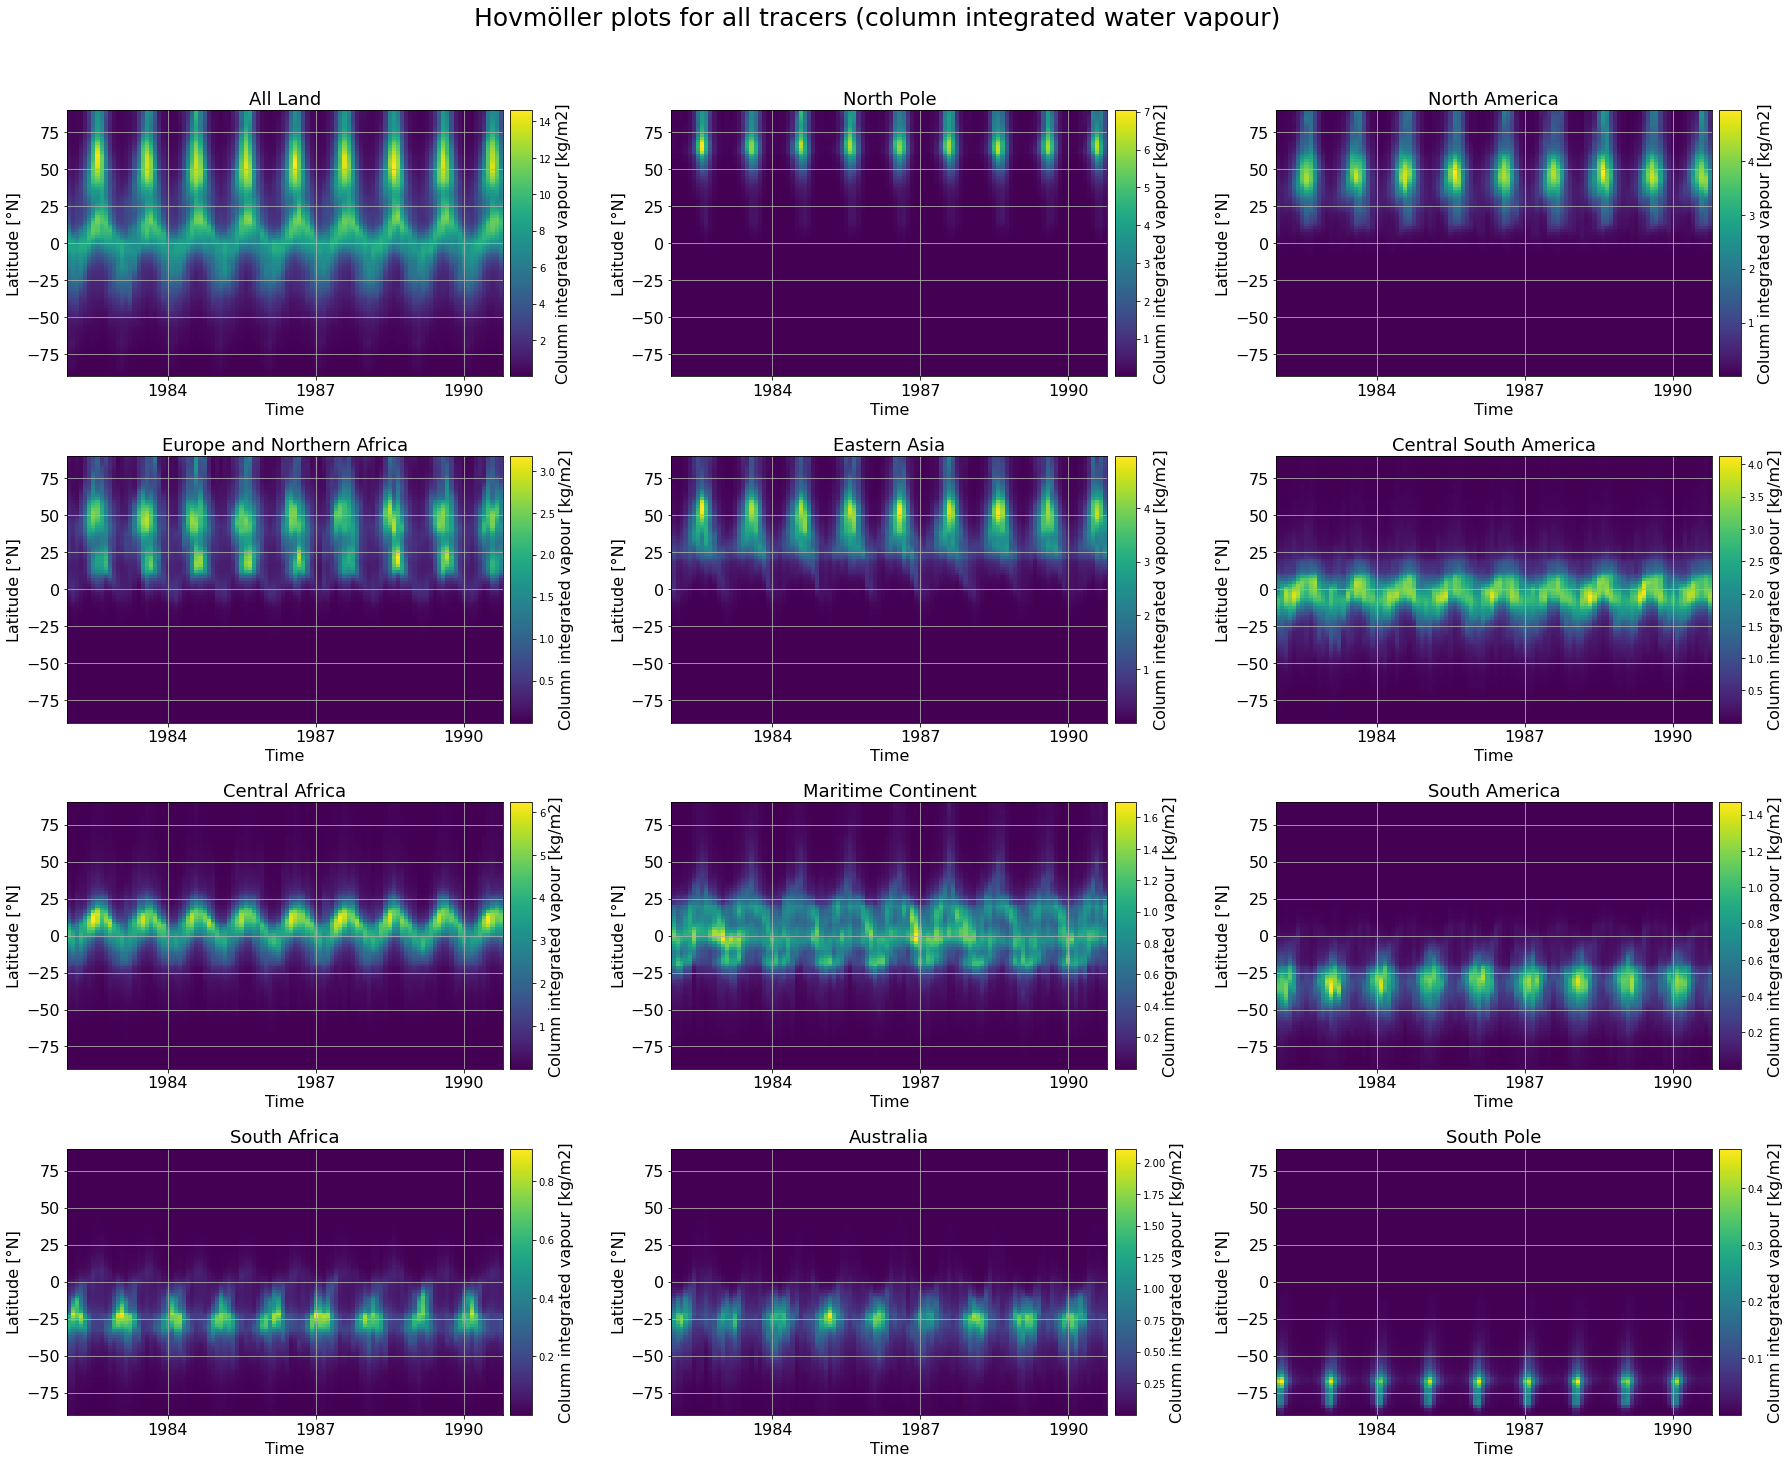

In [35]:
## Hovmöller plot making : all tracer concentration depending on latitude and time at a chosen altitude 
# ------------ CAUTION : different color scale for each tracer -------
case = 'amip'
tracer_list = ['LNDV','NPV', 'NAV', 'EUV','EAV', 'CSAV', 'CAFV','MARV', 'SAV', 'SAFV', 'AUSV', 'SPV']

#general figure layout

fig, axes = plt.subplots(4, 3, figsize=(30, 24))
plt.subplots_adjust(wspace=0.3, hspace=0.3)
ax_list = axes.flatten()

for i, tracer in enumerate(tracer_list):
    ax = ax_list[i]
    data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc")
    tracer_hovm = data_integrated.mean(dim='lon')
    # if only a few years : 
    tracer_hovm = tracer_hovm.isel(time=slice(24, 130))  # Only show 1983-1986 (4 years)
    pcm = ax.pcolormesh(tracer_hovm.time.values, tracer_hovm.lat.values, tracer_hovm.values.T,
                        cmap='viridis',shading='auto')
    #invidual colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cb= fig.colorbar(pcm, cax=cax)
    cb.set_label('Column integrated vapour [kg/m2]', fontsize=16)

    #layout
    ax.set_title(tracer_dict_reversed[tracer], fontsize=18)
    ax.set_xlabel('Time', fontsize=16)
    ax.set_ylabel('Latitude [°N]', fontsize=16)
    ax.set_ylim(-90, 90)
    ax.tick_params(axis='both',labelsize=16)
    ax.grid(True)


fig.suptitle('Hovmöller plots for all tracers (column integrated water vapour)', fontsize=25, y=0.94)
plt.show()
plt.savefig('hovmol_all_3.svg')

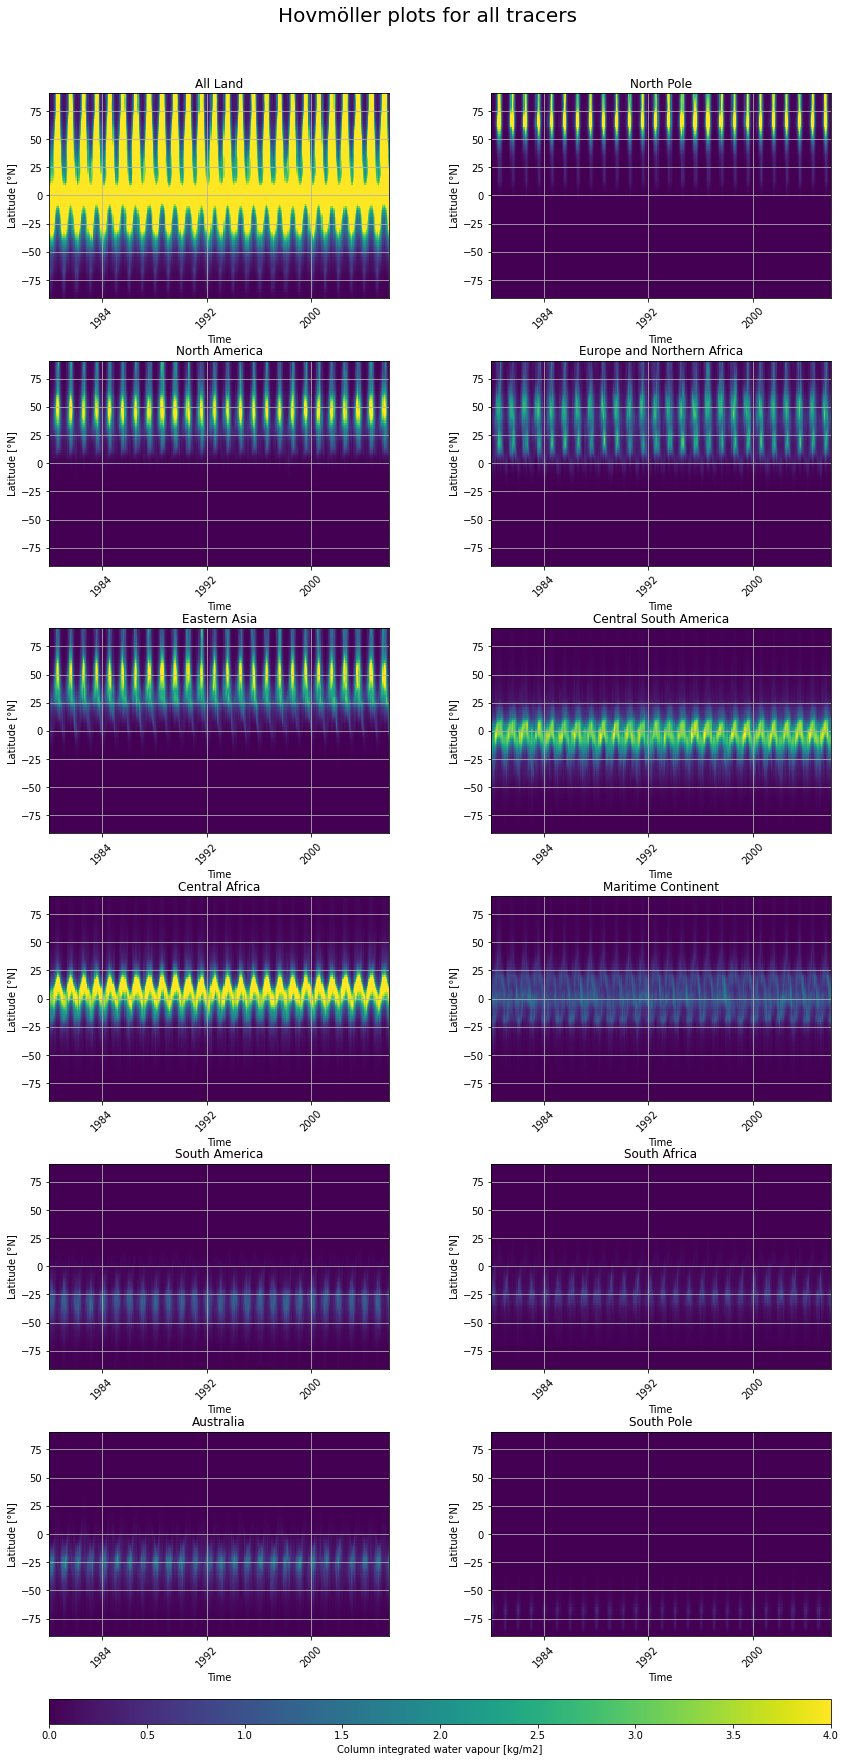

In [12]:
#Overall: Hovmöller plot, column integrated - (mael Secretan) all tracer depending on time and latitude 
#same color scale

case = 'amip'
tracer_list = ['LNDV', 'NPV','NAV', 'EUV','EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV','SPV']
clim = [0.0, 4.] # fixed colorscale, can be changed

#figure settings  : 2x6 figure + 1 colorbar
fig = plt.figure(figsize=(14, 30))
gs = fig.add_gridspec(7, 2,width_ratios=[1, 1],height_ratios=[1, 1, 1, 1, 1, 1, 0.12],wspace=0.3,hspace=0.35)
ax_list = [fig.add_subplot(gs[i // 2, i % 2]) for i in range(12)] # add subplots for 6 lines
ax_cb = fig.add_subplot(gs[6, :]) # colorbar on the last line

pcm = None
for i, tracer in enumerate(tracer_list):
    ax = ax_list[i]
    tracer_zm= xr.open_dataarray("vert_int_output/"+tracer+".nc") # open stored integrated data
    tracer_hovm = tracer_zm.mean(dim='lon')  # shape: (time, lat)

    pcm = ax.pcolormesh(tracer_hovm.time.values,tracer_hovm.lat.values,tracer_hovm.values.T, 
                        cmap='viridis',vmin=clim[0], vmax=clim[1], shading='auto') #plot
    
    # Set title , grid and axis 
    ax.set_title(tracer_dict_reversed[tracer], fontsize=12)
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel('Latitude [°N]', fontsize=10)
    plt.ylim(-90, 90)
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(True)
    
# common colorbar settings 
fig.colorbar(pcm, cax=ax_cb, orientation='horizontal', label='Column integrated water vapour [kg/m2]')
fig.suptitle('Hovmöller plots for all tracers' , fontsize=20, y=0.92) 
plt.show()
plt.close(fig)

#### deferential  Robinson maps ####

In [ ]:
## Differential map plot comparing a chosen year with a refenrence one 
#vertically integrated water vapour for only 1 tracer
#editable to have several selectionned
case = 'amip'
tracer = 'EUV'# tracer choice
year_select = [2002] # year of interest
year_ref= 1984 # ref, eg. the first or most neutral year

# Create the Robinson map figure
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(1,1,1, projection=ccrs.Robinson())

# reference year
data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc") # vertical integration after several years
data_first_year = data_integrated.sel(time=data_integrated.time.dt.year == year_ref).mean('time')#  mean over the ref year

clim = [-1,1] # colorbar limits
for year in year_select :
    data_chosen_year = data_integrated.sel(time=data_integrated.time.dt.year == year).mean('time')#mean over the chosen year
    data_year= data_chosen_year - data_first_year # we want to plot the difference
    data_plot, lon_plot = add_cyclic_point(data_year.values, coord=data_year.lon.values) # Add cyclic point to avoid the white line

    # Plot the data
    pc = ax.pcolormesh(lon_plot, data_year.lat.values, data_plot,transform=ccrs.PlateCarree(), 
                           cmap='RdBu',vmin = clim[0], vmax= clim[1],shading='auto' )
    
    #add coastlines, gridlines colorbar and title
    ax.coastlines()
    ax.gridlines(draw_labels=True,xlocs=[ -20, 60 ],ylocs=[-60, -20, 20, 60])
    cbar = plt.colorbar(pc, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label('Vertically Integrated Water Vapor Tracer [kg/m2]', fontsize=12)
    ax.set_title(f'vapor from {tracer_dict_reversed[tracer]} in {year}', fontsize=16, pad=20)

plt.show()
plt.close(fig)

In [ ]:
## Overall: differential map comparing each year to the mean (for 1 tracer)
case = 'amip'
tracer = 'LNDV' #tracer choice
year_start = 1980
clim = [-2.,2.]

# Create a 14*2 ( 13 lines of plots+ 1 common colorbar )
fig = plt.figure(figsize=(16, 71))                       
gs = fig.add_gridspec(14, 2,height_ratios=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1 , 1, 0.08],hspace=0.)        
ax_list = [fig.add_subplot(gs[i // 2, i % 2], projection=ccrs.Robinson()) for i in range(25)] 
ax_cb = fig.add_subplot(gs[13, :])

data_integrated =xr.open_dataarray("vert_int_output/"+tracer+".nc") # vertical integration for the 1st year
data_tm = data_integrated.mean(dim='time')# calculate mean over time

for i in range (23):
    ax = ax_list[i]
    year= year_start +i
    data_chosen_year = data_integrated.sel(time=data_integrated.time.dt.year == year).mean('time') 
    data_year= data_chosen_year - data_tm # we want to plot the difference
    data_plot, lon_plot = add_cyclic_point(data_year.values, coord=data_year.lon.values) #add yclic point
    figure = ax.pcolormesh(lon_plot, data_year.lat.values, data_plot,transform=ccrs.PlateCarree(), 
                           cmap='RdBu',vmin=clim[0], vmax=clim[1],shading='auto')
    #note statistic of interest
    minimum = data_year.values.min()
    maximum = data_year.values.max()
    mean = data_year.values.mean()
    
    # Add coastlines and title
    ax.coastlines()
    ax.gridlines(draw_labels=True,xlocs=[ -20, 60 ],ylocs=[-60, -20, 20, 60])
    ax.set_title(f'\n {tracer_dict_reversed[tracer]} difference with the mean {year} - mean ', fontsize=14, pad=10) #Vertically Integrated Water Vapor from 
    
    # Add min, max, mean below each map
    text = f"Δmin: {minimum:.3f} |  Δmax: {maximum:.3f}  |  Δmean: {mean:.3f} [kg] "  
    ax.text(0.5, -0.1, text, transform=ax.transAxes,ha='center', va='top', fontsize=12)
    

# Add colorbar
cbar = fig.colorbar(figure, cax=ax_cb, orientation='horizontal')
cbar.set_label('Vertically Integrated Water Vapor difference with the time mean [kg/m2]', fontsize=14)
cbar.ax.tick_params(labelsize=12)
plt.show()

#### classic Robinson maps ####

In [ ]:
#Overall  Robinson map plot of vertically integrated water vapour for 1 tracer, 1 year
case = 'amip'
tracer = 'LNDV'
year_select = [2002]

# Create the Robinson map figure
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(1,1,1, projection=ccrs.Robinson())

for year in year_select :
    data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc") # vertical integration after several years
    data_year = data_integrated.mean('time') #mean over the chosen year

    data_plot, lon_plot = add_cyclic_point(data_year.values, coord=data_year.lon.values) # Add cyclic point to avoid the white line

    # Plot the data and add coastlines, gridlines colorbar and tittle
    pc = ax.pcolormesh(lon_plot, data_year.lat.values, data_plot,transform=ccrs.PlateCarree(), 
                           cmap='viridis',shading='auto')
    ax.coastlines()
    ax.gridlines(draw_labels=True,xlocs=[ -20, 60 ],ylocs=[-60, -20, 20, 60])
    cbar = plt.colorbar(pc, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label('Vertically Integrated Water Vapor Tracer [kg/m2]', fontsize=12)
    ax.set_title(f'vapor from {tracer_dict_reversed[tracer]} in {year}', fontsize=16, pad=20)

plt.show()
plt.close(fig)


In [ ]:
#Overall: map plot of vertically integrated water vapour at different moments for 1 chosen tracer
case = 'amip'
tracer = 'LNDV'#tracer choice
year_select = [1980,1985,1990,1995,2000,2002]

# Create a 3x2 figure with shared colorbar
fig = plt.figure(figsize=(16, 16))
gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1, 0.08], hspace=0.)
ax_list = [fig.add_subplot(gs[i // 2, i % 2], projection=ccrs.Robinson()) for i in range(6)] 
ax_cb  = fig.add_subplot(gs[3, :])

clim =[0,10]# colorscale limits
for i, year in enumerate(year_select):   
    ax = ax_list[i]
    data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc") # open stored integrated data
    data_year = data_integrated.sel(time=data_integrated.time.dt.year == year).mean('time') #mean over the chosen year
    data_plot, lon_plot = add_cyclic_point(data_year.values, coord=data_year.lon.values) #add yclic point
    
    figure = ax.pcolormesh(lon_plot, data_year.lat.values, data_plot,transform=ccrs.PlateCarree(), 
                           cmap='viridis',vmin=clim[0], vmax=clim[1],shading='auto' )
    # Add coastlines and title
    ax.coastlines()
    ax.gridlines(draw_labels=True,xlocs=[ -20, 60 ],ylocs=[-60, -20, 20, 60])
    ax.set_title(f'Vertically Integrated Water Vapor from \n {tracer_dict_reversed[tracer]} - {year}', fontsize=14, pad=10)

# Add colorbar
cbar = fig.colorbar(figure, cax=ax_cb, orientation='horizontal')
cbar.set_label('Vertically Integrated Water Vapor difference with the first year [kg/m2]', fontsize=14)
cbar.ax.tick_params(labelsize=12)
plt.show()

In [ ]:
# Overall: Robinson map plot of vertically integrated water vapour at the start and end for every tracer
#shared colorbar
case = 'amip'
tracer_realnames = ['LNDV','NPV', 'NAV', 'EUV','EAV', 'CSAV', 'CAFV','MARV', 'SAV', 'SAFV', 'AUSV', 'SPV']
year_select = [1980, 2004]

#Create a 12x2 figure + a shared colorbar
fig = plt.figure(figsize=(16, 66))                       
gs = fig.add_gridspec(13, 2,height_ratios=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0.08],hspace=0.)                

ax_list = [[fig.add_subplot(gs[i, j], projection=ccrs.Robinson()) for j in range(2)] for i in range(12)]
ax_cb = fig.add_subplot(gs[12, :])
clim =[0,10]

for i, tracer in enumerate(tracer_realnames):
    data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc")
    for j, year in enumerate(year_select):
        ax = ax_list[i][j]
        data_year = data_integrated.sel(time=data_integrated.time.dt.year == year).mean('time')
        data_plot, lon_plot = add_cyclic_point(data_year.values, coord=data_year.lon.values)
        figure = ax.pcolormesh(lon_plot, data_year.lat.values, data_plot,transform=ccrs.PlateCarree(), 
                           cmap='viridis',vmin=clim[0], vmax=clim[1],shading='auto' )

        ax.coastlines()
        ax.gridlines(draw_labels=True, xlocs=[-20, 60], ylocs=[-60, -20, 20, 60])
        ax.set_title(f'Vertically Integrated Water Vapor from \n{tracer_dict_reversed[tracer]} - {year}',
                     fontsize=14, pad=10)

cbar = fig.colorbar(figure, cax=ax_cb, orientation='horizontal')
cbar.set_label('Vertically Integrated Water Vapor [kg/m2]', fontsize=14)
cbar.ax.tick_params(labelsize=12)
plt.show()